# Baseline Exploration Report

This notebook is a report-style template for analyzing the current TTD baseline before model exploration.

Main goals:
- Compare the baseline model against the no-pretrain variant.
- Identify where the baseline performs poorly.
- Build evidence-based motivation for the next exploration layer.
- Collect qualitative observations from prediction visualizations.


## 1. Setup

Update the paths below only if your folder structure changes.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

PROJECT_ROOT = Path('/users/7/yu001011/csci5527/CSCI5527-final')
BASELINE_CSV = PROJECT_ROOT / 'baseline_models' / 'TTD_baseline_results.csv'
NO_PRETRAIN_CSV = PROJECT_ROOT / 'baseline_models_no_weight' / 'TTD_baseline_no_weight_results.csv'
FIGURE_DIR = PROJECT_ROOT / 'baseline_models' / 'figures'
NO_PRETRAIN_FIGURE_DIR = PROJECT_ROOT / 'baseline_models_no_weight' / 'figures'

BASELINE_CSV, NO_PRETRAIN_CSV

(PosixPath('/users/7/yu001011/csci5527/CSCI5527-final/baseline_models/TTD_baseline_results.csv'),
 PosixPath('/users/7/yu001011/csci5527/CSCI5527-final/baseline_models_no_weight/TTD_baseline_no_weight_results.csv'))

## 2. Load Results

In [2]:
baseline_df = pd.read_csv(BASELINE_CSV)
no_pretrain_df = pd.read_csv(NO_PRETRAIN_CSV)

baseline_df.head()

,Experiment,Val_Loss,Val_IoU,Val_F1,Val_Recall,Val_Prec,Test_Loss,Test_IoU,Test_F1,Test_Recall,Test_Prec
0,Unet-resnet34-imagenet_Single-TA,5.165847,0.689974,0.813734,0.809841,0.821625,4.904795,0.761615,0.864254,0.858492,0.870581
1,Unet-resnet34-imagenet_Single-TB,5.811433,0.425747,0.572554,0.723710,0.521410,6.502544,0.401265,0.569973,0.539100,0.609460
2,Unet-resnet34-imagenet_Single-TC,6.072379,0.362947,0.510956,0.579974,0.496867,5.369856,0.440326,0.611231,0.751428,0.515505
3,Unet-resnet34-imagenet_Multi-Domain,5.724244,0.519445,0.665111,0.720104,0.644484,5.534631,0.570468,0.709008,0.757437,0.673748
4,Unet-resnet34-imagenet_Shift-TA_TB-to-TC_10pct,5.463406,0.590309,0.730546,0.786317,0.704458,5.543253,0.380002,0.549345,0.599940,0.506741


## 3. Normalize Experiment Names

Here we map both result files to the same experiment labels so we can compare `imagenet` vs `no_pretrain` fairly.

In [3]:
def clean_baseline_name(name: str) -> str:
    return name.replace('Unet-resnet34-imagenet_', '')

def clean_no_pretrain_name(name: str) -> str:
    return name.replace('Unet-resnet34-no_weight_', '')

baseline_df = baseline_df.copy()
no_pretrain_df = no_pretrain_df.copy()

baseline_df['Setting'] = baseline_df['Experiment'].apply(clean_baseline_name)
no_pretrain_df['Setting'] = no_pretrain_df['Experiment'].apply(clean_no_pretrain_name)

baseline_df[['Experiment', 'Setting']].head()

,Experiment,Setting
0,Unet-resnet34-imagenet_Single-TA,Single-TA
1,Unet-resnet34-imagenet_Single-TB,Single-TB
2,Unet-resnet34-imagenet_Single-TC,Single-TC
3,Unet-resnet34-imagenet_Multi-Domain,Multi-Domain
4,Unet-resnet34-imagenet_Shift-TA_TB-to-TC_10pct,Shift-TA_TB-to-TC_10pct


## 4. Side-by-Side Comparison

In [4]:
compare_cols = ['Val_IoU', 'Val_F1', 'Test_IoU', 'Test_F1', 'Test_Recall', 'Test_Prec']

merged = baseline_df[['Setting'] + compare_cols].merge(
    no_pretrain_df[['Setting'] + compare_cols],
    on='Setting',
    suffixes=('_imagenet', '_no_pretrain')
)

for col in compare_cols:
    merged[f'{col}_gain'] = merged[f'{col}_imagenet'] - merged[f'{col}_no_pretrain']

merged.sort_values('Test_IoU_gain', ascending=False)

,Setting,Val_IoU_imagenet,Val_F1_imagenet,Test_IoU_imagenet,Test_F1_imagenet,Test_Recall_imagenet,Test_Prec_imagenet,Val_IoU_no_pretrain,Val_F1_no_pretrain,Test_IoU_no_pretrain,Test_F1_no_pretrain,Test_Recall_no_pretrain,Test_Prec_no_pretrain,Val_IoU_gain,Val_F1_gain,Test_IoU_gain,Test_F1_gain,Test_Recall_gain,Test_Prec_gain
9,Shift-TB_TC-to-TA_100pct,0.407161,0.565227,0.605607,0.749473,0.711773,0.800602,0.303092,0.460338,0.383698,0.540823,0.567759,0.546101,0.104069,0.104889,0.221910,0.208651,0.144014,0.254501
8,Shift-TB_TC-to-TA_10pct,0.414023,0.572991,0.562069,0.714822,0.664535,0.778654,0.293101,0.447868,0.350376,0.502205,0.508595,0.526157,0.120923,0.125123,0.211694,0.212617,0.155940,0.252498
6,Shift-TA_TC-to-TB_10pct,0.558676,0.697554,0.336622,0.502192,0.619369,0.448486,0.499514,0.645461,0.130711,0.229476,0.428239,0.159286,0.059162,0.052093,0.205911,0.272716,0.191129,0.289200
7,Shift-TA_TC-to-TB_100pct,0.556211,0.691775,0.247791,0.388040,0.529818,0.324259,0.481824,0.629106,0.088523,0.160065,0.372953,0.108533,0.074387,0.062669,0.159268,0.227975,0.156865,0.215726
1,Single-TB,0.425747,0.572554,0.401265,0.569973,0.539100,0.609460,0.244403,0.390854,0.291384,0.445540,0.574949,0.379461,0.181343,0.181700,0.109881,0.124433,-0.035849,0.229999
4,Shift-TA_TB-to-TC_10pct,0.590309,0.730546,0.380002,0.549345,0.599940,0.506741,0.516593,0.665398,0.321813,0.483199,0.591088,0.411519,0.073716,0.065148,0.058189,0.066146,0.008852,0.095222
2,Single-TC,0.362947,0.510956,0.440326,0.611231,0.751428,0.515505,0.318365,0.465932,0.384747,0.552755,0.749883,0.440651,0.044582,0.045023,0.055579,0.058476,0.001545,0.074855
0,Single-TA,0.689974,0.813734,0.761615,0.864254,0.858492,0.870581,0.617790,0.755586,0.710416,0.830559,0.862360,0.802358,0.072184,0.058148,0.051199,0.033695,-0.003868,0.068223
3,Multi-Domain,0.519445,0.665111,0.570468,0.709008,0.757437,0.673748,0.449410,0.600271,0.520730,0.659196,0.705127,0.632484,0.070035,0.064840,0.049739,0.049812,0.052311,0.041264
5,Shift-TA_TB-to-TC_100pct,0.587422,0.730307,0.271022,0.412525,0.386635,0.491483,0.551767,0.699789,0.241288,0.379118,0.330293,0.483185,0.035655,0.030518,0.029734,0.033407,0.056342,0.008298


In [5]:
summary = merged[['Setting', 'Test_IoU_gain', 'Test_F1_gain', 'Test_Recall_gain', 'Test_Prec_gain']].copy()
summary = summary.sort_values('Test_IoU_gain', ascending=False)
display(summary)

display(Markdown(
    f"Average Test IoU gain from ImageNet pretraining: **{summary['Test_IoU_gain'].mean():.4f}**"
))
display(Markdown(
    f"Average Test F1 gain from ImageNet pretraining: **{summary['Test_F1_gain'].mean():.4f}**"
))

,Setting,Test_IoU_gain,Test_F1_gain,Test_Recall_gain,Test_Prec_gain
9,Shift-TB_TC-to-TA_100pct,0.221910,0.208651,0.144014,0.254501
8,Shift-TB_TC-to-TA_10pct,0.211694,0.212617,0.155940,0.252498
6,Shift-TA_TC-to-TB_10pct,0.205911,0.272716,0.191129,0.289200
7,Shift-TA_TC-to-TB_100pct,0.159268,0.227975,0.156865,0.215726
1,Single-TB,0.109881,0.124433,-0.035849,0.229999
4,Shift-TA_TB-to-TC_10pct,0.058189,0.066146,0.008852,0.095222
2,Single-TC,0.055579,0.058476,0.001545,0.074855
0,Single-TA,0.051199,0.033695,-0.003868,0.068223
3,Multi-Domain,0.049739,0.049812,0.052311,0.041264
5,Shift-TA_TB-to-TC_100pct,0.029734,0.033407,0.056342,0.008298


Average Test IoU gain from ImageNet pretraining: **0.1153**

Average Test F1 gain from ImageNet pretraining: **0.1288**

## 5. Plot the Improvement by Setting

This helps show where pretraining matters the most.

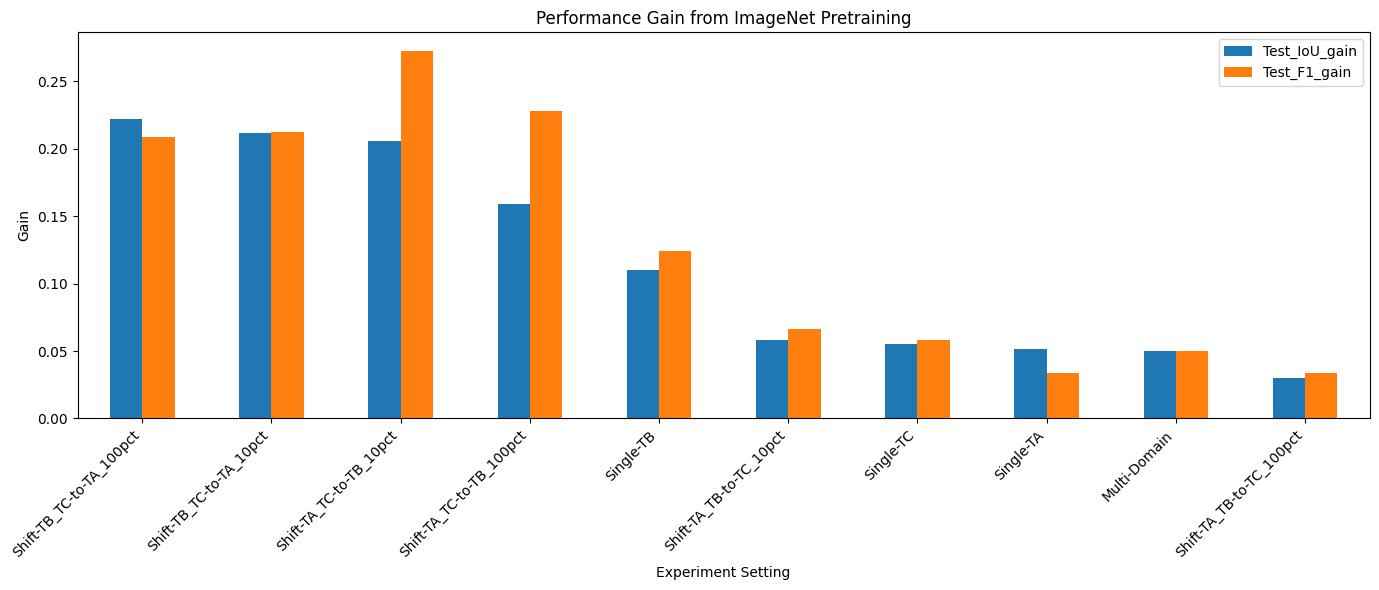

In [6]:
plot_df = summary.set_index('Setting')[['Test_IoU_gain', 'Test_F1_gain']]

ax = plot_df.plot(kind='bar', figsize=(14, 6))
ax.set_title('Performance Gain from ImageNet Pretraining')
ax.set_ylabel('Gain')
ax.set_xlabel('Experiment Setting')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Focus on Hard Cases

This table isolates the settings where baseline performance is weak. These are the most useful settings for motivating the second exploration layer.

In [7]:
hard_cases = baseline_df[['Setting', 'Test_IoU', 'Test_F1', 'Test_Recall', 'Test_Prec']].copy()
hard_cases = hard_cases.sort_values('Test_IoU')
display(hard_cases)

display(Markdown(
    "Suggested focus: choose 2-3 lowest-performing settings and inspect their visualization outputs in detail."
))

,Setting,Test_IoU,Test_F1,Test_Recall,Test_Prec
7,Shift-TA_TC-to-TB_100pct,0.247791,0.388040,0.529818,0.324259
5,Shift-TA_TB-to-TC_100pct,0.271022,0.412525,0.386635,0.491483
6,Shift-TA_TC-to-TB_10pct,0.336622,0.502192,0.619369,0.448486
4,Shift-TA_TB-to-TC_10pct,0.380002,0.549345,0.599940,0.506741
1,Single-TB,0.401265,0.569973,0.539100,0.609460
2,Single-TC,0.440326,0.611231,0.751428,0.515505
8,Shift-TB_TC-to-TA_10pct,0.562069,0.714822,0.664535,0.778654
3,Multi-Domain,0.570468,0.709008,0.757437,0.673748
9,Shift-TB_TC-to-TA_100pct,0.605607,0.749473,0.711773,0.800602
0,Single-TA,0.761615,0.864254,0.858492,0.870581


Suggested focus: choose 2-3 lowest-performing settings and inspect their visualization outputs in detail.

## 8. Load Baseline Visualization Examples

The code below displays the saved prediction-overlap images. Pick the settings you want to discuss in your report.

### Unet-resnet34-imagenet_Single-TB_visualization.png

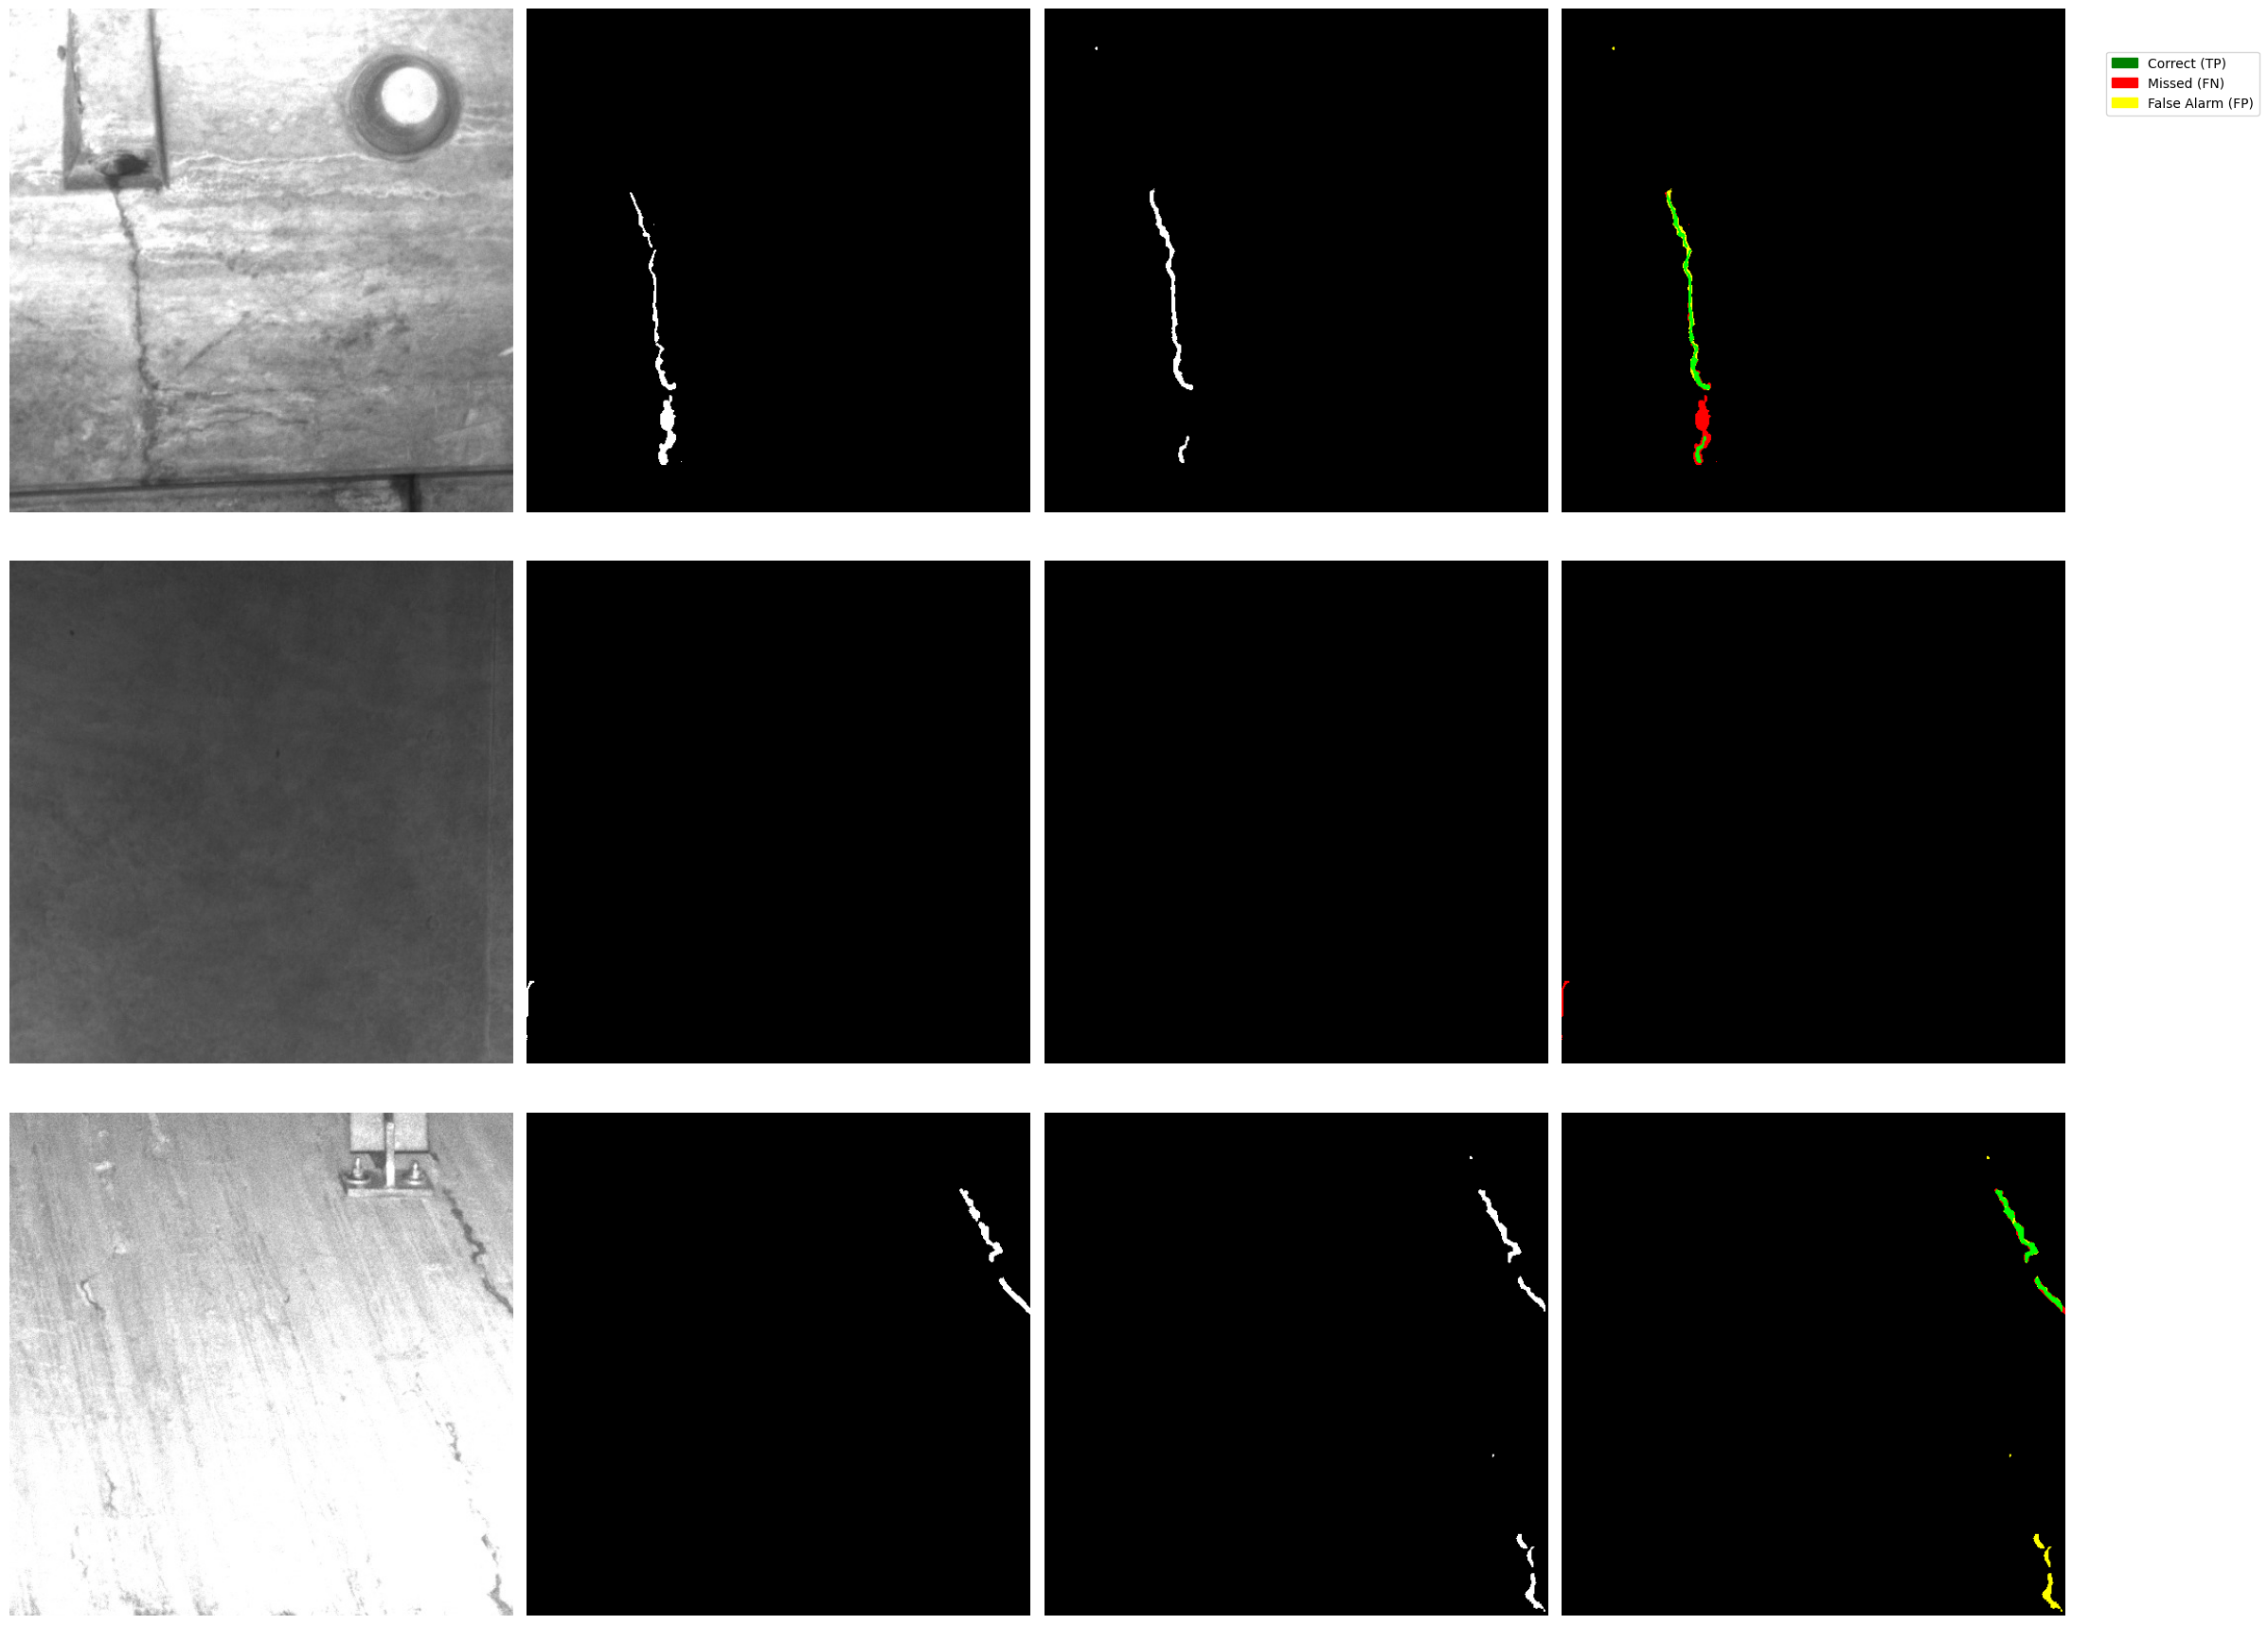

### Unet-resnet34-imagenet_Single-TC_visualization.png

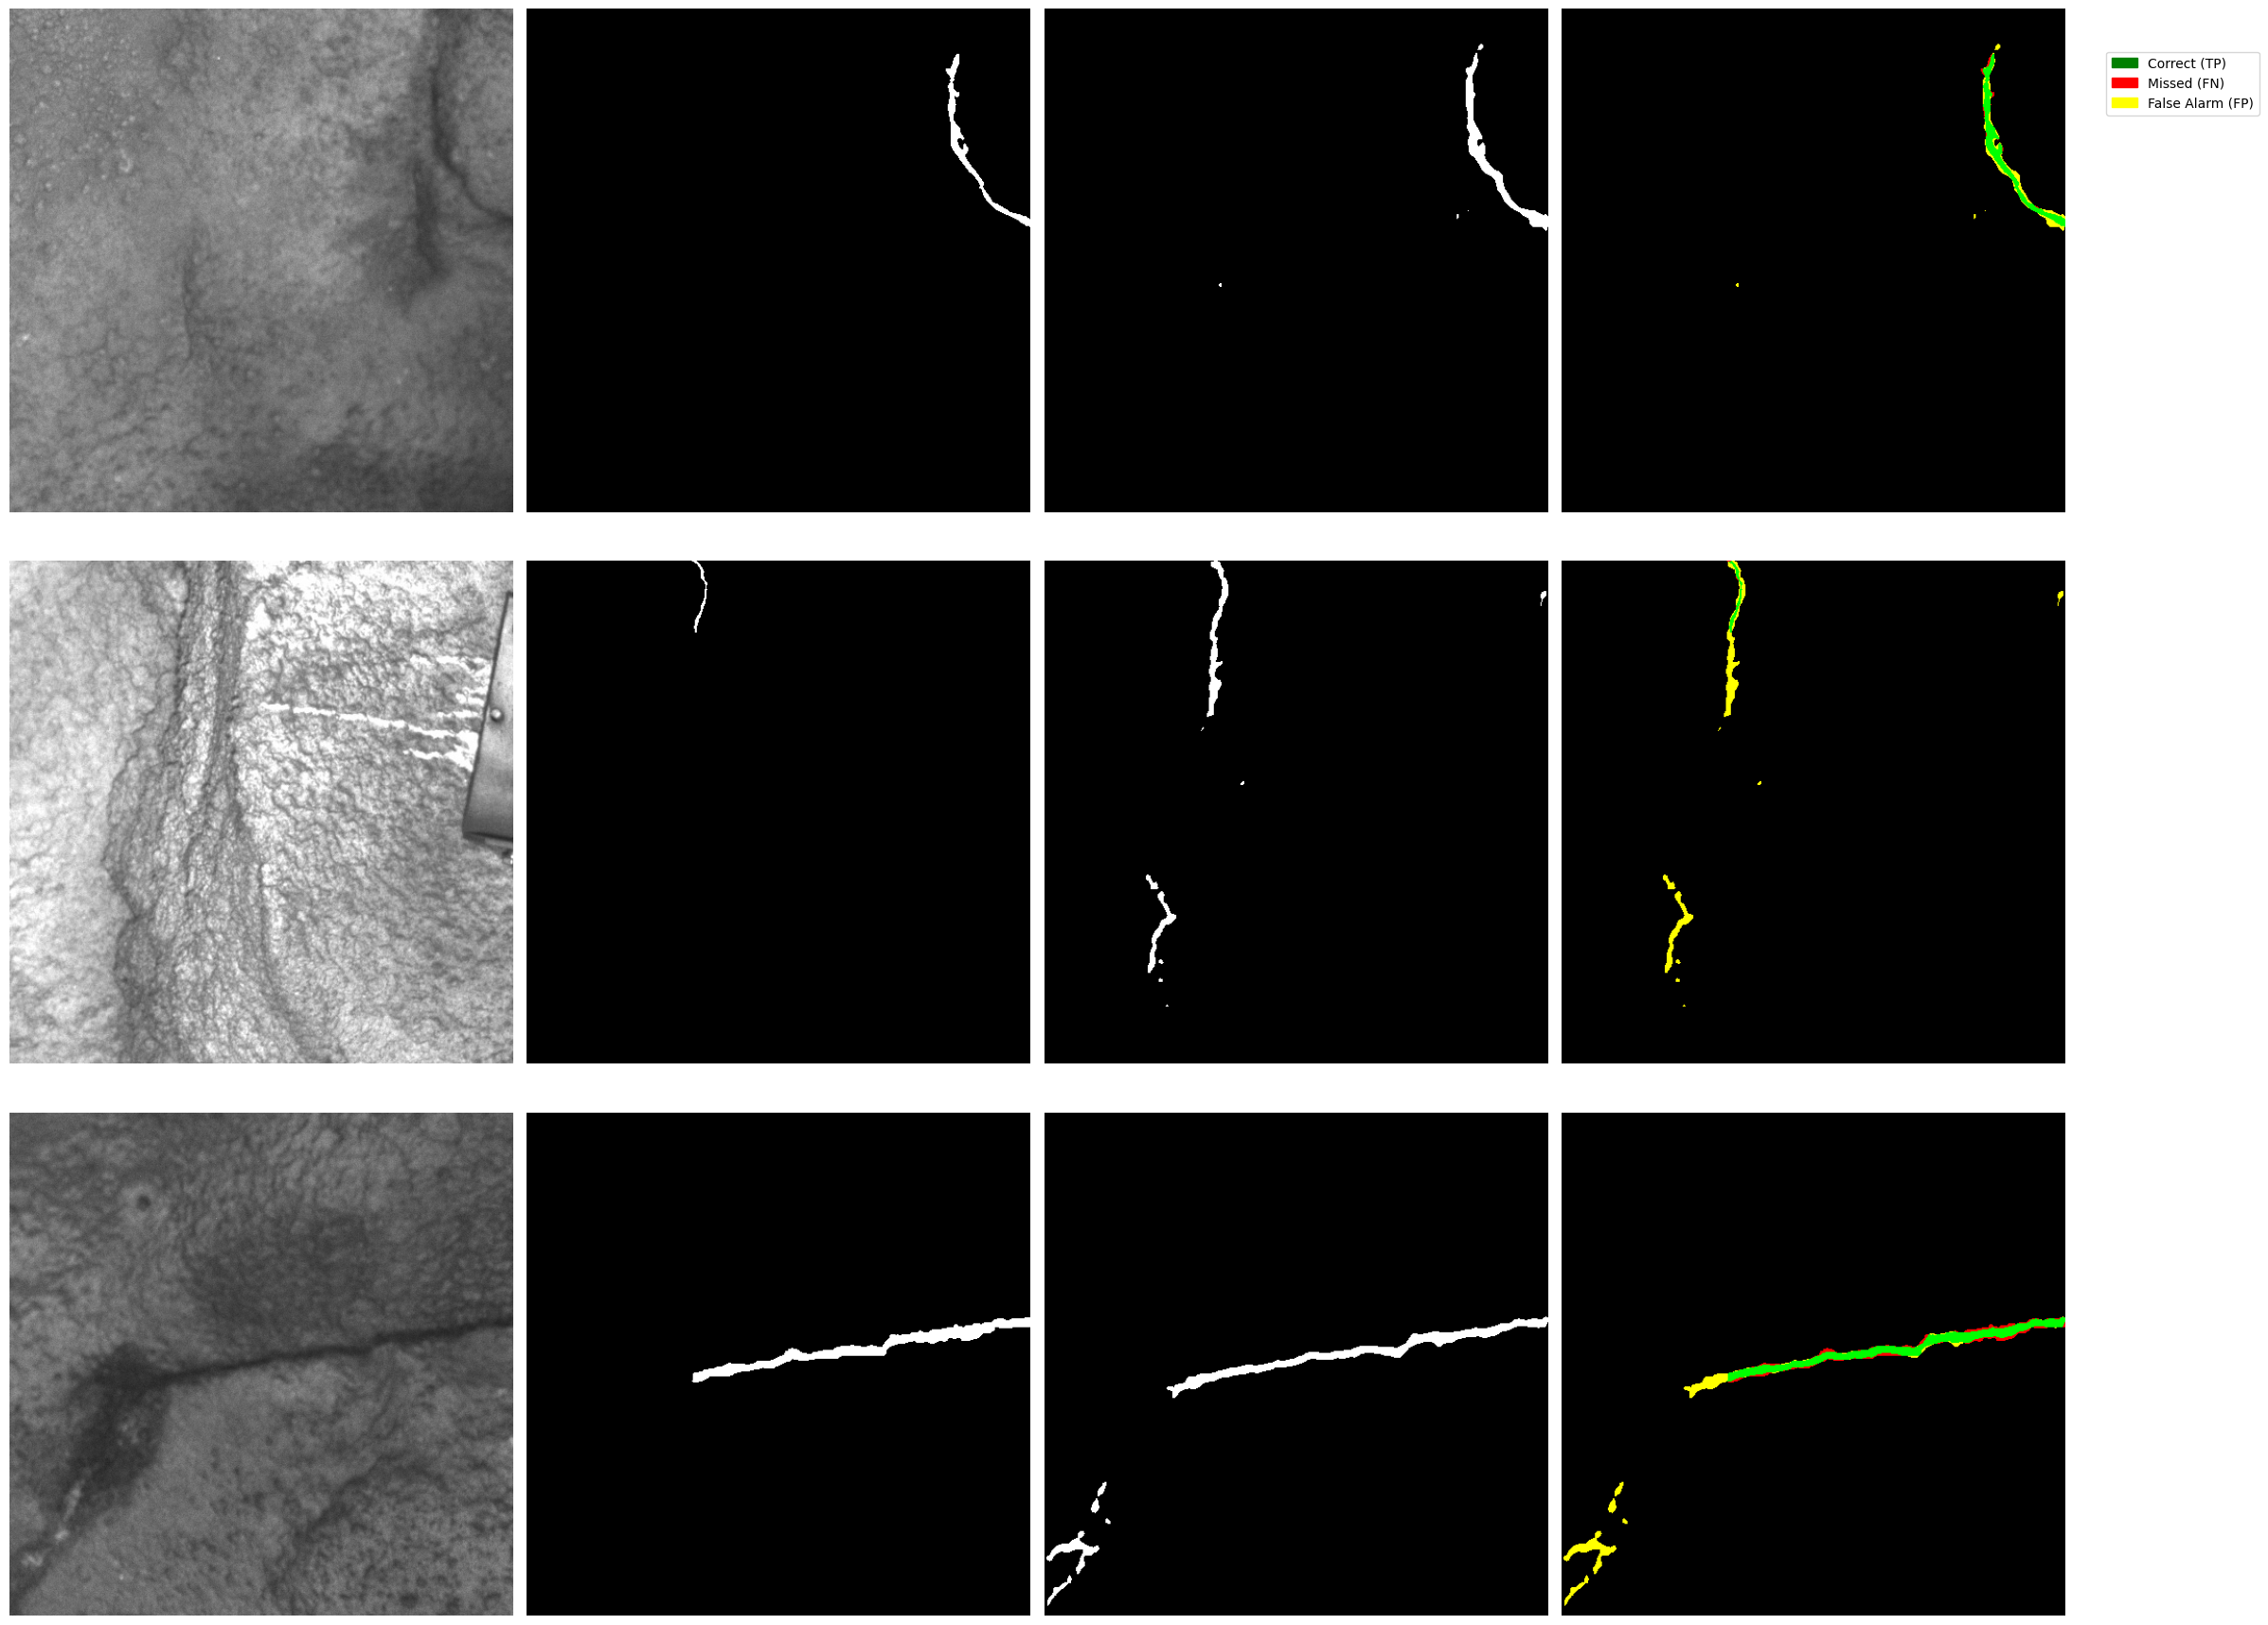

### Unet-resnet34-imagenet_Shift-TA_TC-to-TB_10pct_visualization.png

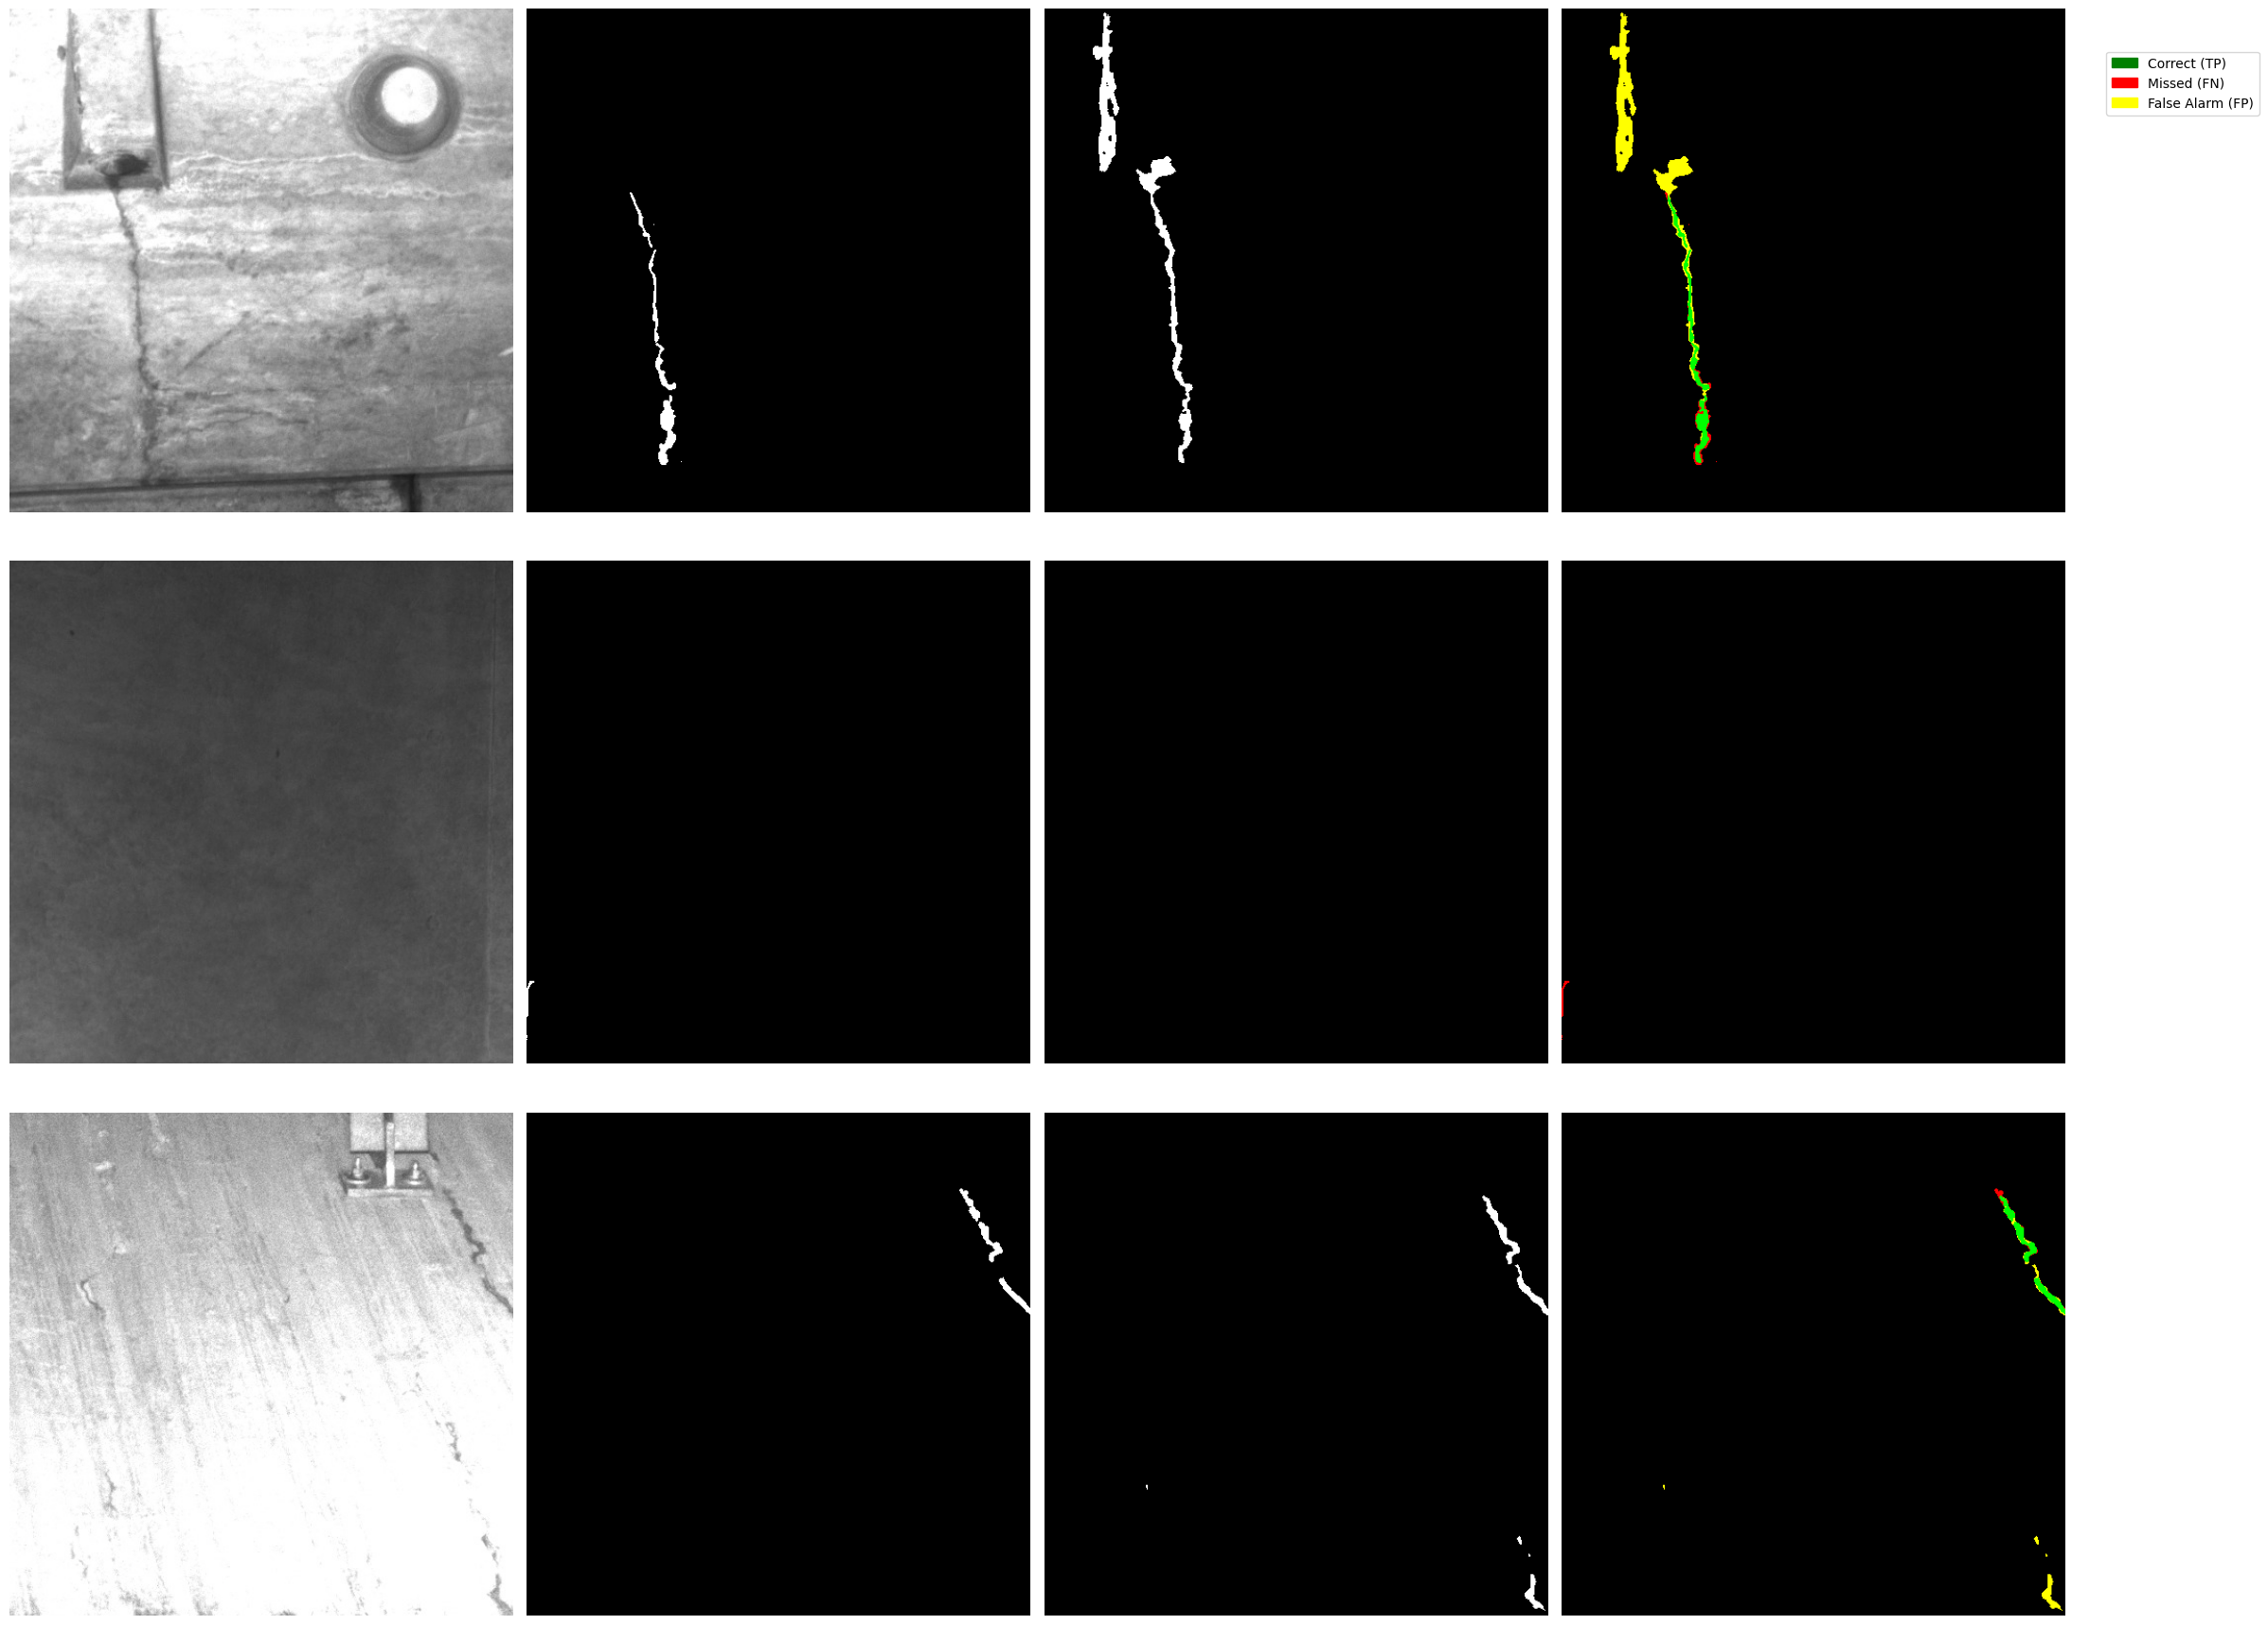

### Unet-resnet34-imagenet_Shift-TA_TB-to-TC_100pct_visualization.png

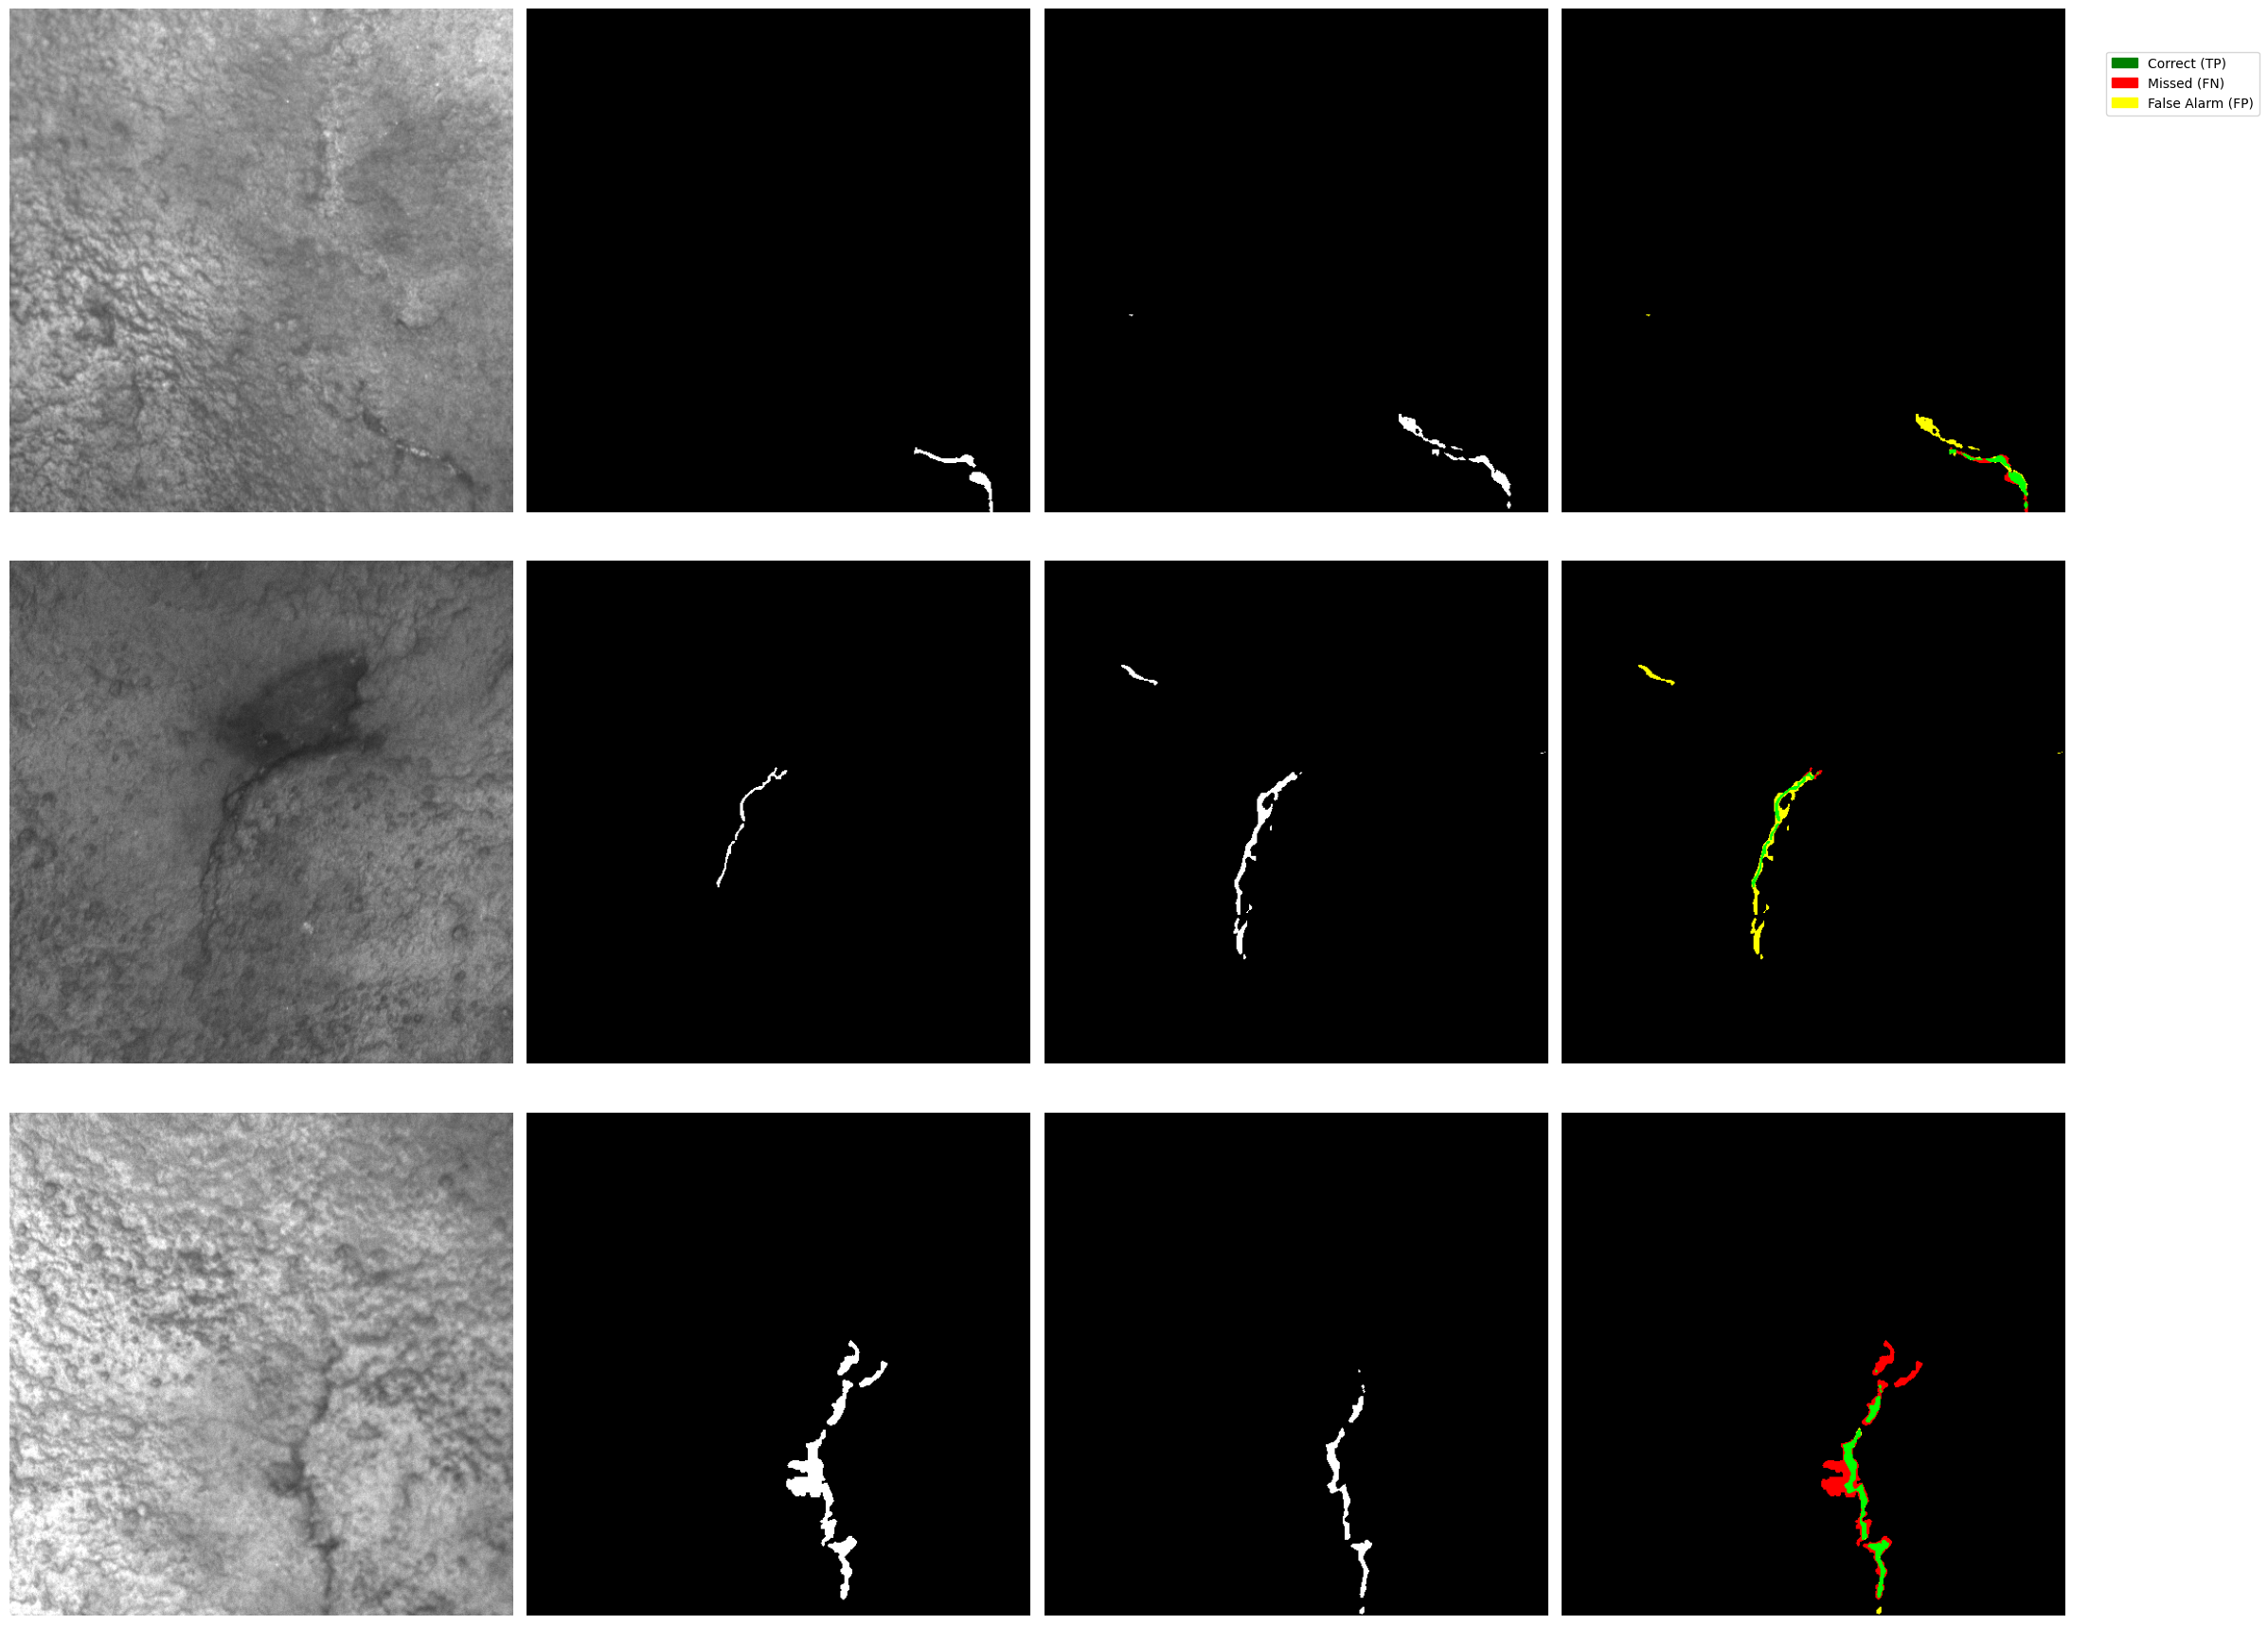

In [8]:
def show_figure(folder: Path, filename: str, width: int = 900):
    path = folder / filename
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f'Figure not found: `{path}`'))

example_figures = [
    'Unet-resnet34-imagenet_Single-TB_visualization.png',
    'Unet-resnet34-imagenet_Single-TC_visualization.png',
    'Unet-resnet34-imagenet_Shift-TA_TC-to-TB_10pct_visualization.png',
    'Unet-resnet34-imagenet_Shift-TA_TB-to-TC_100pct_visualization.png',
]

for fig in example_figures:
    display(Markdown(f'### {fig}'))
    show_figure(FIGURE_DIR, fig)

## 8B. Worst-Case Visualization From Saved Checkpoints

This section loads a trained checkpoint, rebuilds the matching test dataloader, scores each test image one by one, and saves the worst-performing samples based on per-sample IoU.

Use this when you want to inspect hard examples instead of only the first few positive-mask images.

In [9]:
import sys
import torch

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from baseline_models_scripts.train_ttd import EXPERIMENTS, baseline_model_pipeline, build_model, safe_name
from utils import save_worst_prediction_overlap

MODEL_DIR = PROJECT_ROOT / 'baseline_models' / 'models'
WORST_FIGURE_DIR = PROJECT_ROOT / 'analysis' / 'worst_case_figures'

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [10]:
# Change this to any experiment name from the baseline table.
TARGET_SETTING = 'Shift-TA_TC-to-TB_10pct'
ARCH = 'Unet'
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
BATCH_SIZE = 16
IMG_SIZE = 512

In [11]:
exp_cfg = EXPERIMENTS[TARGET_SETTING]
_, _, test_dl, custom_stats, df_test_ready = baseline_model_pipeline(
    base_dir=PROJECT_ROOT,
    dict_files=exp_cfg,
    bs=BATCH_SIZE,
    img_size=IMG_SIZE,
)

model = build_model(
    arch=ARCH,
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    classes=2,
)

model_name = safe_name(f'{ARCH}-{ENCODER}-{ENCODER_WEIGHTS}_{TARGET_SETTING}')
ckpt_path = MODEL_DIR / f'{model_name}.pth'
assert ckpt_path.exists(), f'Checkpoint not found: {ckpt_path}'

model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.to(device)
ckpt_path

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 936/936 [00:00<00:00, 4043.06it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 48/48 [00:00<00:00, 4265.67it/s]


Generating Dataloaders...

Pipeline Ready:
 - Training batches: 45
 - Validation batches: 13
 - Testing batches: 3


Path('/users/7/yu001011/csci5527/CSCI5527-final/baseline_models/models/Unet-resnet34-imagenet_Shift-TA_TC-to-TB_10pct.pth')

Worst-case visualization saved to /users/7/yu001011/csci5527/CSCI5527-final/analysis/worst_case_figures/Unet-resnet34-imagenet_Shift-TA_TC-to-TB_10pct_worst_iou.png


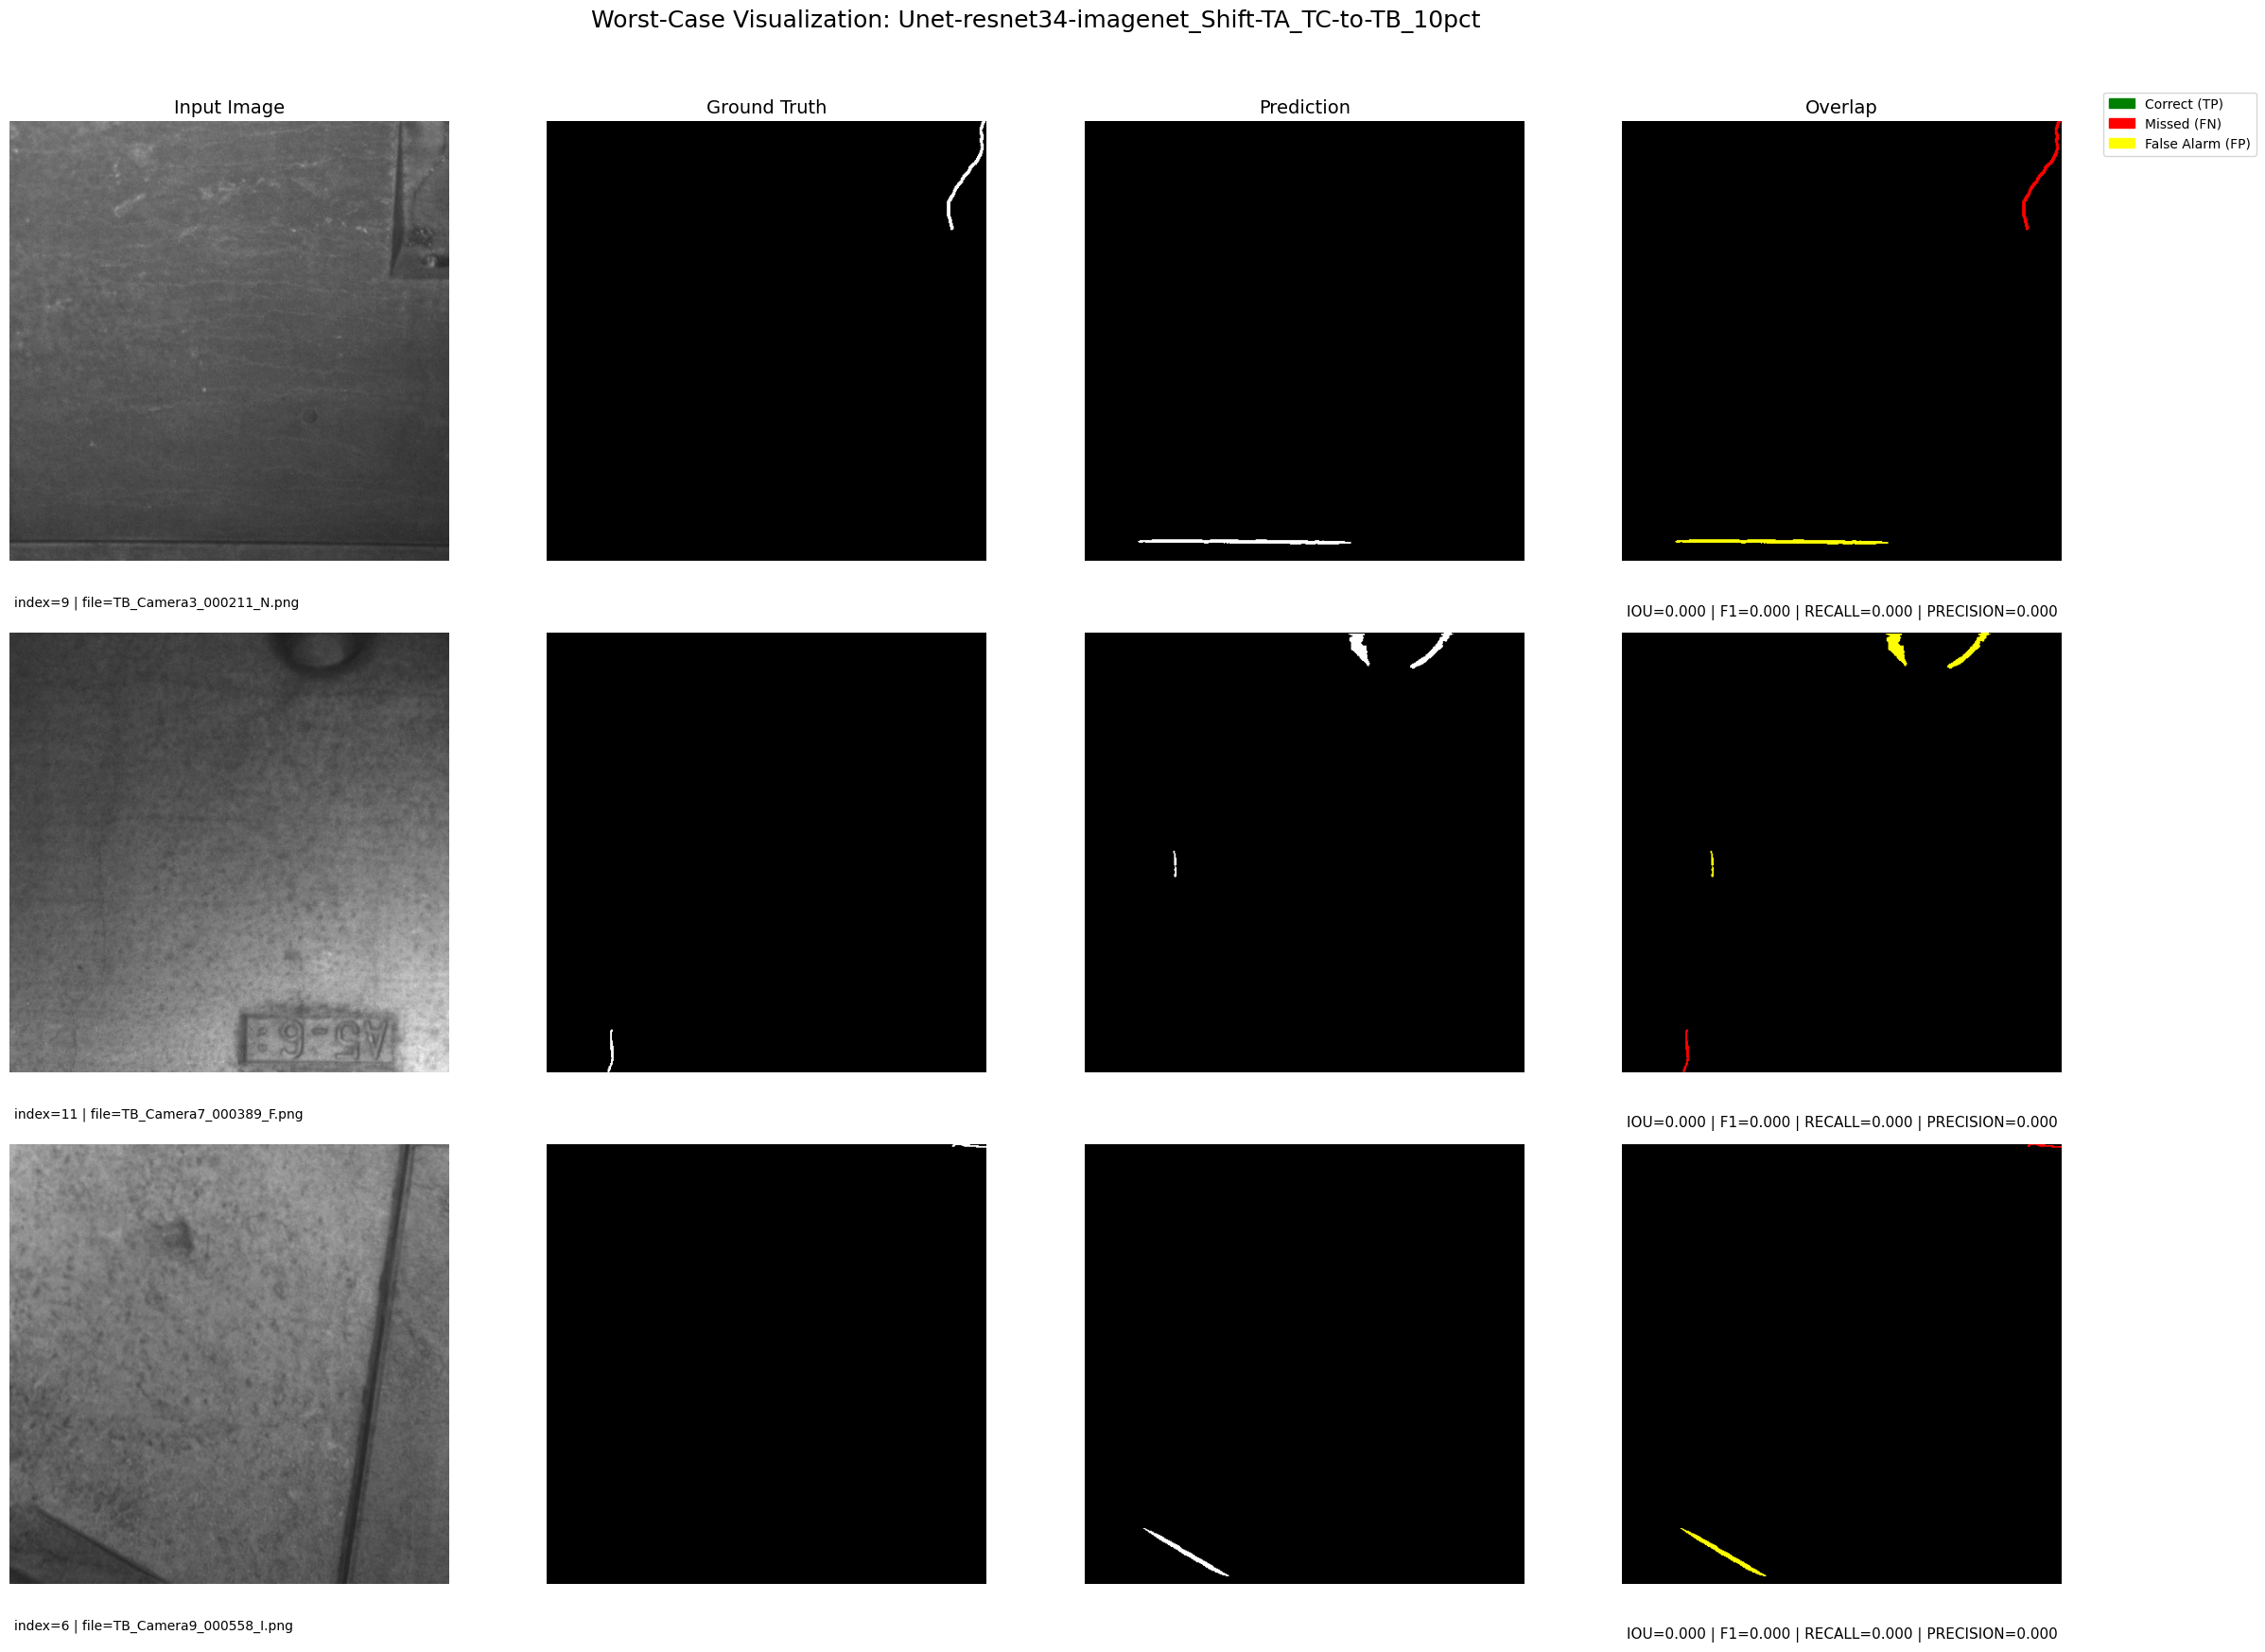

In [12]:
save_worst_prediction_overlap(
    model=model,
    model_name=model_name,
    dataloader=test_dl,
    device=device,
    custom_stats=custom_stats,
    save_dir=str(WORST_FIGURE_DIR),
    top_k=3,
    ranking_metric='iou',
    defects_only=True,
    sample_records=df_test_ready.reset_index(drop=True),
)

worst_fig_path = WORST_FIGURE_DIR / f'{model_name}_worst_iou.png'
display(Image(filename=str(worst_fig_path), width=1100))

## 9. Qualitative Failure Analysis Notes

Use this section like a report draft. Replace the placeholder text with your own observations.

### Example observation template

- Setting:
- Main failure type:
- Evidence from visualization:
- Likely reason:
- What model property might help:

### Example write-up

- Setting: `Single-TB`
- Main failure type: false positives on strong tunnel texture
- Evidence from visualization: multiple yellow regions appear on textured background rather than annotated crack areas
- Likely reason: baseline features may not separate crack texture from non-crack surface patterns well enough
- What model property might help: a stronger encoder with better texture representation


## 10. Motivation for Layer 2 Backbone Exploration

Write the second-layer motivation by connecting baseline weaknesses to model properties.

### Suggested structure

1. What does the baseline do well?
2. Where does it fail?
3. What kind of representation seems missing?
4. Why does a new backbone specifically address that issue?

### Example paragraph

The baseline Unet-resnet34 with ImageNet pretraining performs reasonably well on easier settings, but its performance drops substantially on harder domains and domain-shift scenarios. Qualitative inspection shows missed thin cracks and unstable predictions on complex textured surfaces. These patterns suggest that the current encoder may not extract sufficiently robust fine-grained and multi-scale features. Therefore, the second exploration layer focuses on backbone replacement, such as EfficientNet-based encoders, to test whether stronger and more efficient feature extraction improves robustness and segmentation quality on difficult settings.


## 11. Candidate Backbone Table

You can customize this table before putting it into a report.

In [13]:
candidate_backbones = pd.DataFrame([
    {
        'Backbone': 'resnet34',
        'Role': 'baseline reference',
        'Why test it': 'keep as anchor for fair comparison',
        'Expected strength': 'stable baseline behavior',
    },
    {
        'Backbone': 'efficientnet-b0',
        'Role': 'stronger feature extractor',
        'Why test it': 'may capture texture and scale variation better than resnet34',
        'Expected strength': 'better performance on thin cracks and harder domains',
    },
    {
        'Backbone': 'resnet50',
        'Role': 'deeper residual encoder',
        'Why test it': 'tests whether more capacity improves domain robustness',
        'Expected strength': 'stronger representation on complex scenes',
    },
    {
        'Backbone': 'mobilenet_v2',
        'Role': 'efficiency baseline',
        'Why test it': 'checks if lightweight backbones can retain acceptable quality',
        'Expected strength': 'good speed-accuracy tradeoff',
    },
])

candidate_backbones

,Backbone,Role,Why test it,Expected strength
0,resnet34,baseline reference,keep as anchor for fair comparison,stable baseline behavior
1,efficientnet-b0,stronger feature extractor,may capture texture and scale variation better than resnet34,better performance on thin cracks and harder domains
2,resnet50,deeper residual encoder,tests whether more capacity improves domain robustness,stronger representation on complex scenes
3,mobilenet_v2,efficiency baseline,checks if lightweight backbones can retain acceptable quality,good speed-accuracy tradeoff


## 12. Final Report Draft Prompts

Use these prompts to write the discussion section.

- What quantitative evidence shows pretraining is useful?
- Which settings are still weak even after pretraining?
- What failure patterns appear repeatedly in visualization results?
- Based on these failures, what should the next model exploration target?
- Which backbone is the most justified next step, and why?
